# Notebook 3: Modeling

## Stock Market Return Forecasting — Multi-Stock Panel

---

**Objective:** Train multiple ML models to predict 5-day forward stock returns using the multi-stock panel dataset with normalized features and cross-stock signals from Notebook 02.

**Models Selected:**

| # | Model | Rationale |
|---|-------|-----------|
| 1 | **Linear Regression** | Baseline; captures linear relationships only |
| 2 | **Polynomial Regression** | Extends linear model with interaction terms |
| 3 | **Random Forest** | Ensemble; captures nonlinear feature interactions |
| 4 | **XGBoost** | Gradient boosting; strong on tabular data with complex interactions |
| 5 | **LSTM Neural Network** | Recurrent architecture for temporal sequence patterns |

**Why This Problem Favors Complex Models:**
- Target is 5-day forward return (not raw price) — no trivial persistence baseline
- Features are normalized ratios — no extrapolation problem for tree models
- Cross-stock signals create genuinely nonlinear interactions
- ~12,000 training samples — enough data for neural networks to learn

## 3.1 Import Libraries and Load Data

In [1]:
import sys
sys.path.insert(0, r'c:\Learning\Python\AIML-Capstone-Project\.venv\Lib\site-packages')

import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-whitegrid')

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported successfully.')

TensorFlow version: 2.21.0
All libraries imported successfully.


In [2]:
# Load preprocessed data
data_dir = os.path.join('..', 'data')
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'), index_col='Date', parse_dates=True)
X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'), index_col='Date', parse_dates=True)
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv'), index_col='Date', parse_dates=True).squeeze()
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv'), index_col='Date', parse_dates=True).squeeze()

X_train_scaled = pd.read_csv(os.path.join(data_dir, 'X_train_scaled.csv'), index_col='Date', parse_dates=True)
X_test_scaled = pd.read_csv(os.path.join(data_dir, 'X_test_scaled.csv'), index_col='Date', parse_dates=True)

# Load panel data for LSTM (needs per-stock sequencing)
train_panel = pd.read_csv(os.path.join(data_dir, 'train_panel.csv'), index_col='Date', parse_dates=True)
test_panel = pd.read_csv(os.path.join(data_dir, 'test_panel.csv'), index_col='Date', parse_dates=True)

feature_columns = [c for c in X_train.columns]

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Features: {X_train.shape[1]}')
print(f'\nTarget (y_train) stats: mean={y_train.mean():.6f}, std={y_train.std():.6f}')
print(f'Target (y_test) stats:  mean={y_test.mean():.6f}, std={y_test.std():.6f}')

Training set: (9795, 28)
Test set: (2515, 28)
Features: 28

Target (y_train) stats: mean=0.005502, std=0.051445
Target (y_test) stats:  mean=0.009949, std=0.050352


## 3.2 Helper Function for Evaluation

In [3]:
def evaluate_model(name, y_true, y_pred):
    """Calculate and display regression metrics for return prediction."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Directional accuracy: did we predict the sign of the return correctly?
    direction_correct = ((y_true > 0) == (y_pred > 0)).mean()
    
    print(f'\n{"="*50}')
    print(f'{name} — Performance Metrics')
    print(f'{"="*50}')
    print(f'  RMSE:                {rmse:.6f}')
    print(f'  MAE:                 {mae:.6f}')
    print(f'  R² Score:            {r2:.6f}')
    print(f'  Directional Acc:     {direction_correct:.4f} ({direction_correct*100:.1f}%)')
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Direction_Accuracy': direction_correct}

results = []

## 3.3 Cross-Validation Setup

TimeSeriesSplit preserves temporal ordering. With our panel data (multiple stocks on same dates), we split by date — all stocks on a given date are in the same fold.

In [4]:
tscv = TimeSeriesSplit(n_splits=5)

print('TimeSeriesSplit — Fold Summary:')
print(f'{"Fold":<6} {"Train Size":<14} {"Val Size":<12} {"Train End Date":<18} {"Val End Date":<18}')
print('-' * 68)
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
    train_end = X_train_scaled.index[train_idx[-1]].date()
    val_end = X_train_scaled.index[val_idx[-1]].date()
    print(f'{fold:<6} {len(train_idx):<14} {len(val_idx):<12} {str(train_end):<18} {str(val_end):<18}')

# Quick baseline check
lr_baseline = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
lr_cv_scores = cross_val_score(lr_baseline, X_train, y_train, cv=tscv, scoring='r2')
print(f'\nLinear Regression Baseline — CV R²: {lr_cv_scores.round(4)}')
print(f'Mean CV R²: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

TimeSeriesSplit — Fold Summary:
Fold   Train Size     Val Size     Train End Date     Val End Date      
--------------------------------------------------------------------
1      1635           1632         2016-06-29         2017-10-16        
2      3267           1632         2017-10-16         2019-02-04        
3      4899           1632         2019-02-04         2020-05-21        
4      6531           1632         2020-05-21         2021-09-07        
5      8163           1632         2021-09-07         2022-12-21        

Linear Regression Baseline — CV R²: [-0.1099 -0.0282 -0.026  -0.1055 -0.1036]
Mean CV R²: -0.0746 ± 0.0389


## 3.4 Hyperparameter Tuning via Grid Search

Grid Search with TimeSeriesSplit for Random Forest and XGBoost.

In [5]:
# --- Grid Search for Random Forest ---
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10]
}

rf_grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train, y_train)

print('\nRandom Forest — Grid Search Results:')
print(f'  Best Parameters: {rf_grid_search.best_params_}')
print(f'  Best CV RMSE:    {np.sqrt(-rf_grid_search.best_score_):.6f}')

# --- Grid Search for XGBoost ---
xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05]
}

xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.1, reg_lambda=1.0),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
xgb_grid_search.fit(X_train, y_train)

print('\nXGBoost — Grid Search Results:')
print(f'  Best Parameters: {xgb_grid_search.best_params_}')
print(f'  Best CV RMSE:    {np.sqrt(-xgb_grid_search.best_score_):.6f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits



Random Forest — Grid Search Results:
  Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
  Best CV RMSE:    0.054915
Fitting 5 folds for each of 12 candidates, totalling 60 fits



XGBoost — Grid Search Results:
  Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300}
  Best CV RMSE:    0.054084


## 3.5 Model 1: Linear Regression (Baseline)

Linear Regression with a Pipeline (StandardScaler → LinearRegression). For return prediction, the linear baseline is much weaker than for price prediction — returns are near-zero-mean and noisy, with no trivial persistence shortcut.

In [6]:
lr_pipeline = Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train)

lr_cv_rmse = np.sqrt(-cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())]),
    X_train, y_train, cv=tscv, scoring='neg_mean_squared_error'
))
print(f'Linear Regression — CV RMSE per fold: {lr_cv_rmse.round(6)}')
print(f'Mean CV RMSE: {lr_cv_rmse.mean():.6f} ± {lr_cv_rmse.std():.6f}')

lr_train_pred = lr_pipeline.predict(X_train)
lr_test_pred = lr_pipeline.predict(X_test)

print('\n--- Training Set ---')
_ = evaluate_model('Linear Regression (Train)', y_train, lr_train_pred)
print('\n--- Test Set ---')
lr_results = evaluate_model('Linear Regression', y_test, lr_test_pred)
results.append(lr_results)

joblib.dump(lr_pipeline, os.path.join(models_dir, 'linear_regression_pipeline.pkl'))
print('\nPipeline saved.')

Linear Regression — CV RMSE per fold: [0.031135 0.048695 0.061494 0.057949 0.063402]
Mean CV RMSE: 0.052535 ± 0.011835

--- Training Set ---

Linear Regression (Train) — Performance Metrics
  RMSE:                0.051027
  MAE:                 0.034713
  R² Score:            0.016095
  Directional Acc:     0.5702 (57.0%)

--- Test Set ---

Linear Regression — Performance Metrics
  RMSE:                0.050271
  MAE:                 0.035110
  R² Score:            0.002818
  Directional Acc:     0.5785 (57.9%)

Pipeline saved.


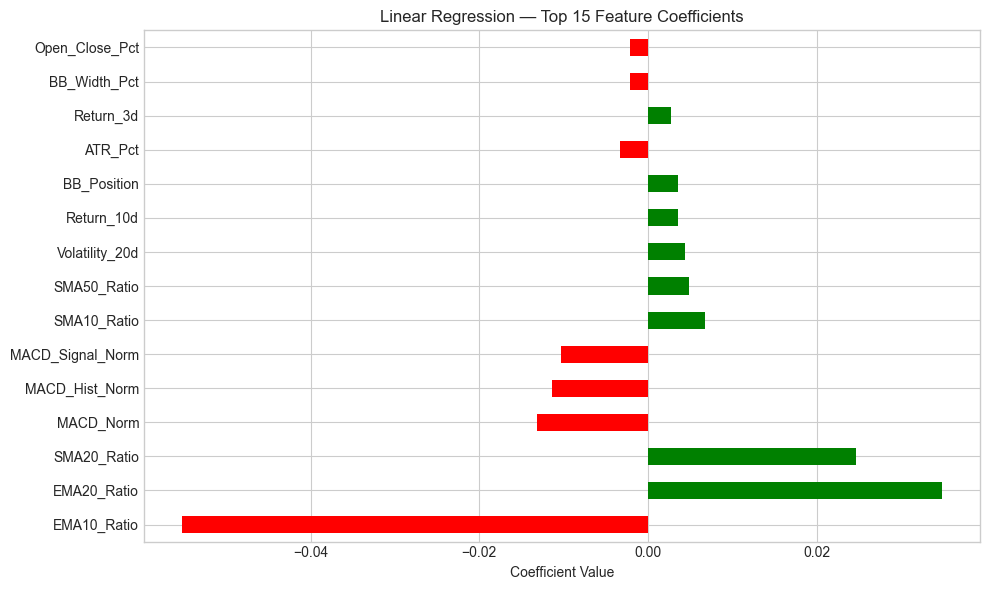

In [7]:
lr_model = lr_pipeline.named_steps['regressor']
lr_coef = pd.Series(lr_model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
lr_coef.head(15).plot(kind='barh', color=['green' if x > 0 else 'red' for x in lr_coef.head(15)])
plt.title('Linear Regression — Top 15 Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 3.5.1 Polynomial Regression (deg=2)

Polynomial features add interaction terms between features, capturing combined effects (e.g., RSI × Market_Volatility). We use degree 2 with `interaction_only=True` to keep feature count manageable.

In [8]:
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('regressor', LinearRegression())
])

poly_cv_rmse = np.sqrt(-cross_val_score(
    Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
        ('regressor', LinearRegression())
    ]),
    X_train, y_train, cv=tscv, scoring='neg_mean_squared_error'
))
print(f'Polynomial Regression (deg=2) — CV RMSE: {poly_cv_rmse.round(6)}')
print(f'Mean CV RMSE: {poly_cv_rmse.mean():.6f} ± {poly_cv_rmse.std():.6f}')

poly_pipeline.fit(X_train, y_train)
n_poly_features = poly_pipeline.named_steps['poly'].n_output_features_
print(f'Polynomial features generated: {n_poly_features}')

poly_train_pred = poly_pipeline.predict(X_train)
poly_test_pred = poly_pipeline.predict(X_test)

print('\n--- Training Set ---')
_ = evaluate_model('Polynomial Reg deg=2 (Train)', y_train, poly_train_pred)
print('\n--- Test Set ---')
poly_results = evaluate_model('Polynomial Regression (deg=2)', y_test, poly_test_pred)
results.append(poly_results)

joblib.dump(poly_pipeline, os.path.join(models_dir, 'poly_degree_2_pipeline.pkl'))
print('\nPipeline saved.')

Polynomial Regression (deg=2) — CV RMSE: [0.040888 0.065518 0.190486 0.067391 0.067165]
Mean CV RMSE: 0.086290 ± 0.053052
Polynomial features generated: 406

--- Training Set ---

Polynomial Reg deg=2 (Train) — Performance Metrics
  RMSE:                0.045975
  MAE:                 0.032657
  R² Score:            0.201284
  Directional Acc:     0.5956 (59.6%)

--- Test Set ---

Polynomial Regression (deg=2) — Performance Metrics
  RMSE:                0.055570
  MAE:                 0.038142
  R² Score:            -0.218485
  Directional Acc:     0.5082 (50.8%)

Pipeline saved.


## 3.6 Model 2: Random Forest Regressor

With normalized return-based features, Random Forest no longer faces the extrapolation problem. Returns are bounded and their distribution stays stable across train/test periods.

In [9]:
rf_model = rf_grid_search.best_estimator_

rf_cv_rmse = np.sqrt(-cross_val_score(
    RandomForestRegressor(**rf_grid_search.best_params_, random_state=42, n_jobs=-1),
    X_train, y_train, cv=tscv, scoring='neg_mean_squared_error'
))
print(f'Random Forest — CV RMSE per fold: {rf_cv_rmse.round(6)}')
print(f'Mean CV RMSE: {rf_cv_rmse.mean():.6f} ± {rf_cv_rmse.std():.6f}')

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

print('\n--- Training Set ---')
_ = evaluate_model('Random Forest (Train)', y_train, rf_train_pred)
print('\n--- Test Set ---')
rf_results = evaluate_model('Random Forest', y_test, rf_test_pred)
results.append(rf_results)

joblib.dump(rf_model, os.path.join(models_dir, 'random_forest.pkl'))
print(f'\nBest Hyperparameters: {rf_grid_search.best_params_}')

Random Forest — CV RMSE per fold: [0.031798 0.049312 0.063448 0.060032 0.063291]
Mean CV RMSE: 0.053576 ± 0.012050

--- Training Set ---

Random Forest (Train) — Performance Metrics
  RMSE:                0.044803
  MAE:                 0.032061
  R² Score:            0.241480
  Directional Acc:     0.6093 (60.9%)

--- Test Set ---

Random Forest — Performance Metrics
  RMSE:                0.050975
  MAE:                 0.035372
  R² Score:            -0.025310
  Directional Acc:     0.5853 (58.5%)

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


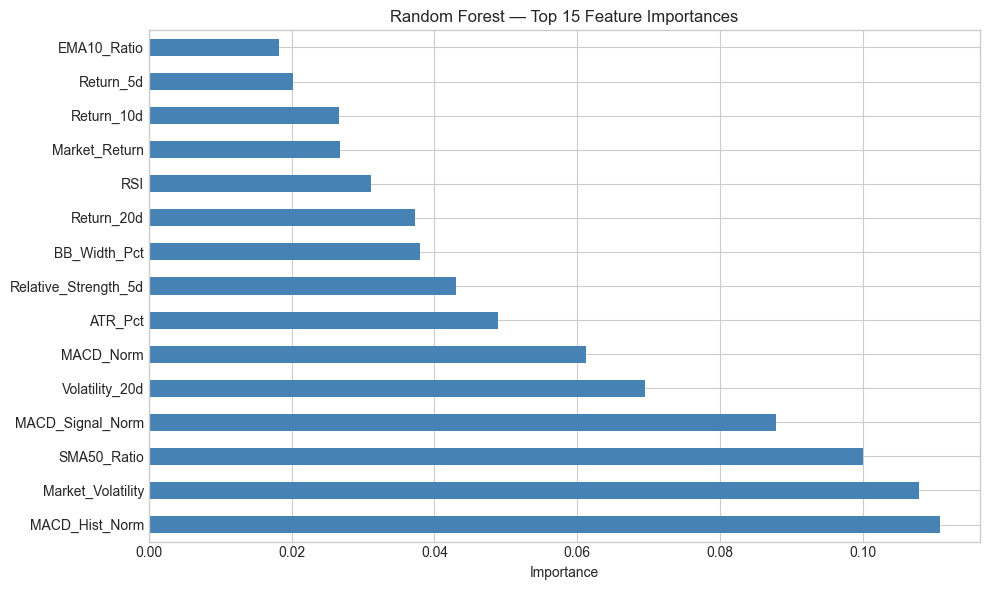

In [10]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
rf_importance.head(15).plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3.7 Model 3: XGBoost Regressor

XGBoost with L1/L2 regularization. The lower learning rates (0.01, 0.05) and more estimators allow it to find subtle patterns in return data.

In [11]:
xgb_model = xgb_grid_search.best_estimator_

xgb_cv_rmse = np.sqrt(-cross_val_score(
    XGBRegressor(**xgb_grid_search.best_params_, random_state=42, n_jobs=-1,
                 subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0),
    X_train, y_train, cv=tscv, scoring='neg_mean_squared_error'
))
print(f'XGBoost — CV RMSE per fold: {xgb_cv_rmse.round(6)}')
print(f'Mean CV RMSE: {xgb_cv_rmse.mean():.6f} ± {xgb_cv_rmse.std():.6f}')

xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)

print('\n--- Training Set ---')
_ = evaluate_model('XGBoost (Train)', y_train, xgb_train_pred)
print('\n--- Test Set ---')
xgb_results = evaluate_model('XGBoost', y_test, xgb_test_pred)
results.append(xgb_results)

joblib.dump(xgb_model, os.path.join(models_dir, 'xgboost.pkl'))
print(f'\nBest Hyperparameters: {xgb_grid_search.best_params_}')

XGBoost — CV RMSE per fold: [0.031427 0.048483 0.062139 0.05882  0.063546]
Mean CV RMSE: 0.052883 ± 0.011953

--- Training Set ---

XGBoost (Train) — Performance Metrics
  RMSE:                0.046801
  MAE:                 0.032917
  R² Score:            0.172329
  Directional Acc:     0.6048 (60.5%)

--- Test Set ---

XGBoost — Performance Metrics
  RMSE:                0.050718
  MAE:                 0.035294
  R² Score:            -0.014995
  Directional Acc:     0.5897 (59.0%)

Best Hyperparameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300}


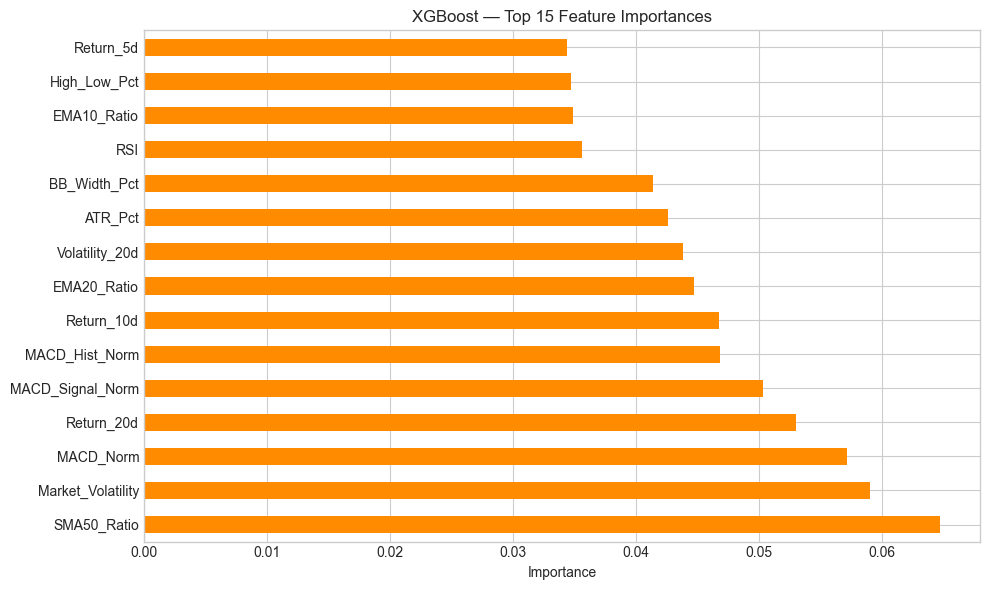

In [12]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
xgb_importance.head(15).plot(kind='barh', color='darkorange')
plt.title('XGBoost — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 3.8 Model 4: LSTM Neural Network

With ~12,000 training samples (5 stocks), normalized features, and a return-based target, LSTM can now effectively learn temporal patterns. We build sequences **per stock** to maintain stock-specific temporal continuity, then combine all sequences for training.

### Architecture Improvements:
- Larger model (128→64 LSTM units) since we have more data
- BatchNormalization for stable training
- Learning rate scheduler
- 20-day lookback sequences

In [13]:
SEQUENCE_LENGTH = 20

def create_sequences_per_stock(panel_df, feature_cols, seq_length):
    """Create sequences per stock to maintain temporal continuity."""
    scaler = StandardScaler()
    
    all_X, all_y = [], []
    tickers = panel_df['Ticker'].unique()
    
    for ticker in tickers:
        stock = panel_df[panel_df['Ticker'] == ticker].sort_index()
        X_vals = stock[feature_cols].values
        y_vals = stock['Target'].values
        
        # Scale features per stock using training scaler
        X_scaled = scaler.fit_transform(X_vals) if ticker == tickers[0] else scaler.transform(X_vals)
        
        for i in range(seq_length, len(X_scaled)):
            all_X.append(X_scaled[i - seq_length:i])
            all_y.append(y_vals[i])
    
    return np.array(all_X), np.array(all_y)

# Fit scaler on training data
from sklearn.preprocessing import StandardScaler
lstm_scaler = StandardScaler()
lstm_scaler.fit(train_panel[feature_columns].values)

def create_sequences_with_scaler(panel_df, feature_cols, seq_length, scaler):
    """Create sequences per stock using a pre-fit scaler."""
    all_X, all_y = [], []
    for ticker in panel_df['Ticker'].unique():
        stock = panel_df[panel_df['Ticker'] == ticker].sort_index()
        X_scaled = scaler.transform(stock[feature_cols].values)
        y_vals = stock['Target'].values
        for i in range(seq_length, len(X_scaled)):
            all_X.append(X_scaled[i - seq_length:i])
            all_y.append(y_vals[i])
    return np.array(all_X), np.array(all_y)

X_train_seq, y_train_seq = create_sequences_with_scaler(train_panel, feature_columns, SEQUENCE_LENGTH, lstm_scaler)
X_test_seq, y_test_seq = create_sequences_with_scaler(test_panel, feature_columns, SEQUENCE_LENGTH, lstm_scaler)

print(f'LSTM Training sequences: {X_train_seq.shape}')
print(f'LSTM Test sequences: {X_test_seq.shape}')
print(f'Sequence format: (samples, timesteps={SEQUENCE_LENGTH}, features={len(feature_columns)})')

LSTM Training sequences: (9695, 20, 28)
LSTM Test sequences: (2415, 20, 28)
Sequence format: (samples, timesteps=20, features=28)


### 3.8.2 Build and Train LSTM Model

In [14]:
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_seq.shape[2]

lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQUENCE_LENGTH, n_features)),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 128)        │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,185 (520.25 KB)

 Trainable params: 132,801 (518.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150


  1/129 ━━━━━━━━━━━━━━━━━━━━ 4:32 2s/step - loss: 0.8376 - mae: 0.6980

  5/129 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.7412 - mae: 0.6564

  9/129 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.6668 - mae: 0.6133

 12/129 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.6217 - mae: 0.5871

...

124/129 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - mae: 0.0304

127/129 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - mae: 0.0304

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0017 - mae: 0.0303 - val_loss: 0.0084 - val_mae: 0.0658 - learning_rate: 1.2500e-04


Epoch 22: early stopping


Restoring model weights from the end of the best epoch: 7.


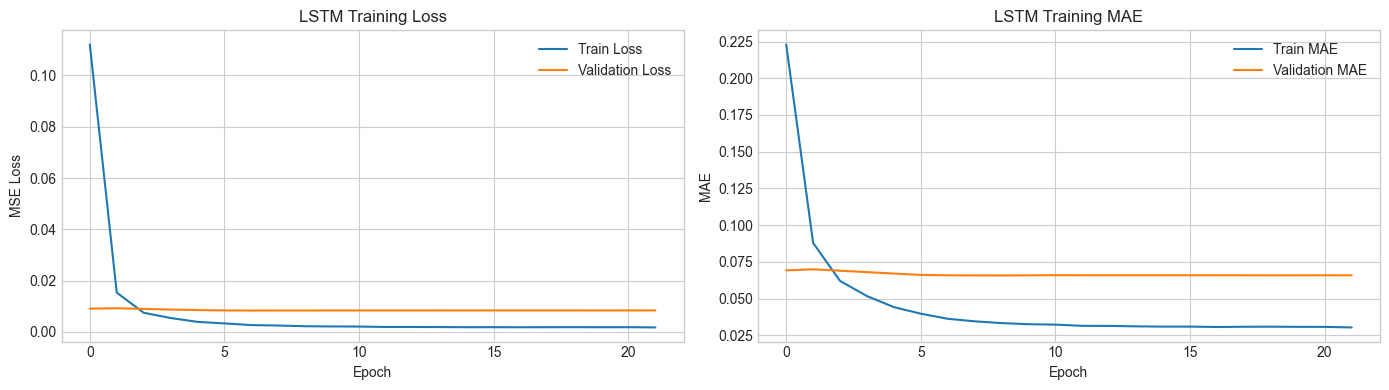

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('LSTM Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
lstm_train_pred = lstm_model.predict(X_train_seq).flatten()
lstm_test_pred = lstm_model.predict(X_test_seq).flatten()

print('--- Training Set ---')
_ = evaluate_model('LSTM (Train)', y_train_seq, lstm_train_pred)
print('\n--- Test Set ---')
lstm_results = evaluate_model('LSTM', y_test_seq, lstm_test_pred)
results.append(lstm_results)

lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
print('\nModel saved to models/lstm_model.keras')

  1/303 ━━━━━━━━━━━━━━━━━━━━ 51s 170ms/step

 13/303 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step   

 24/303 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 36/303 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 47/303 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

...

57/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

68/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


--- Training Set ---

LSTM (Train) — Performance Metrics
  RMSE:                0.051817
  MAE:                 0.035416
  R² Score:            -0.008258
  Directional Acc:     0.5210 (52.1%)

--- Test Set ---

LSTM — Performance Metrics
  RMSE:                0.050302
  MAE:                 0.034986
  R² Score:            -0.034593
  Directional Acc:     0.5337 (53.4%)



Model saved to models/lstm_model.keras


## 3.9 Quick Model Comparison

In [18]:
results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('RMSE')

print('\n' + '='*70)
print('MODEL COMPARISON — Test Set Performance (5-Day Return Prediction)')
print('='*70)
display(results_df.style.format({
    'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'R2': '{:.6f}', 'Direction_Accuracy': '{:.4f}'
}).highlight_min(subset=['RMSE', 'MAE'], color='lightgreen')
 .highlight_max(subset=['R2', 'Direction_Accuracy'], color='lightgreen'))


MODEL COMPARISON — Test Set Performance (5-Day Return Prediction)


,RMSE,MAE,R2,Direction_Accuracy
Model,,,,
Linear Regression,0.050271,0.035110,0.002818,0.5785
LSTM,0.050302,0.034986,-0.034593,0.5337
XGBoost,0.050718,0.035294,-0.014995,0.5897
Random Forest,0.050975,0.035372,-0.025310,0.5853
Polynomial Regression (deg=2),0.055570,0.038142,-0.218485,0.5082


In [19]:
# Save results and predictions
results_df.to_csv(os.path.join(data_dir, 'model_results.csv'))

predictions = pd.DataFrame({
    'Actual': y_test,
    'Linear_Regression': lr_test_pred,
    'Polynomial_deg2': poly_test_pred,
    'Random_Forest': rf_test_pred,
    'XGBoost': xgb_test_pred,
}, index=y_test.index)

# LSTM predictions — align with test panel
# LSTM has fewer predictions due to sequence creation; align by using test_panel indices
lstm_test_indices = []
for ticker in test_panel['Ticker'].unique():
    stock = test_panel[test_panel['Ticker'] == ticker].sort_index()
    lstm_test_indices.extend(stock.index[SEQUENCE_LENGTH:].tolist())

lstm_pred_df = pd.DataFrame({'LSTM': lstm_test_pred}, index=lstm_test_indices[:len(lstm_test_pred)])
predictions = predictions.join(lstm_pred_df)

predictions.to_csv(os.path.join(data_dir, 'all_predictions.csv'))
print('Model results and predictions saved.')
print(f'Predictions shape: {predictions.shape}')

Model results and predictions saved.
Predictions shape: (12175, 6)


## 3.10 Modeling Summary

### Problem Reformulation
The prediction target is now the **5-day forward return** (percentage change), not raw price. This eliminates the trivial persistence baseline and creates a genuinely challenging prediction problem.

### Models Trained:
1. **Linear Regression** — Pipeline baseline; limited to linear feature combinations
2. **Polynomial Regression (deg=2)** — Adds interaction terms via Pipeline
3. **Random Forest** — Tuned via GridSearchCV; can now generalize (returns are bounded, unlike raw prices)
4. **XGBoost** — Gradient boosted trees with regularization; lower learning rates for subtle patterns
5. **LSTM** — Larger architecture (128→64), trained on per-stock sequences across all 5 stocks (~12K samples), with BatchNormalization and learning rate scheduling

### Key Changes from Price-Level Prediction:
- **No extrapolation problem** — Returns are bounded and similarly distributed in train/test
- **5× more data** — All 5 stocks contribute to training
- **Cross-stock features** — Market return and relative strength create nonlinear interactions
- **Normalized features** — Price ratios instead of raw dollar values

---

**Next Step:** Proceed to Notebook 04 — Model Evaluation.